In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [64]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context) # current running context ...,..e,.em, emm, mma,ma.
      Y.append(ix) #current char
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # remove first item and add target char

  X = torch.tensor(X) #each row contains 3 char context
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [66]:
Xtr.shape, Ytr.dtype, Xdev.shape, Ydev.dtype

(torch.Size([182625, 3]), torch.int64, torch.Size([22655, 3]), torch.int64)

In [ ]:
C = torch.randn((27,2)) #rand nums two col

In [ ]:
C[5]

In [ ]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C #trigger 5th index as high

In [ ]:
X[13,2]

In [ ]:
C[X][13,2] #multi dimensional, Replace every index in X with corresponding row from C
#take example #13
#take 3rd character in context (index 2)

#Returns that character’s embedding vector.

In [ ]:
C[1]

In [ ]:
emb = C[X]
emb.shape

In [ ]:
w1 = torch.randn((6,100))
b1 = torch.randn(100)

In [ ]:
emb @ w1 + b1

In [ ]:
torch.cat([emb[:,0,:], emb[:,0,:], emb[:,2, :]],1) #concat at dim 1 i.e 1st index not 0th

In [ ]:
torch.cat(torch.unbind(emb,1),1).shape

In [ ]:
h = torch.tanh(emb.view(-1,6) @ w1 + b1) # hidden layer frwd pass with 32, 2 *3=>32,6
# -1 means infer batch size automatically, 32-> shape becomes 32,6. 64-> shape becomes 64,6

In [ ]:
h #32 examples with each example represented by 100 learned hidden features
h.shape

In [ ]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
logits = h @ W2 + b2

In [ ]:
logits.shape

In [ ]:
counts = logits.exp()

In [ ]:
prob = counts / counts.sum(1, keepdims=True)

In [ ]:
prob.shape

In [ ]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

In [67]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g) # 3* n-> 3*10
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [68]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [69]:
for p in parameters:
  p.requires_grad = True

In [70]:
lre = torch.linspace(-3, 0, 1000) #1k steps/numbers btwn -3 and 0
lrs = 10**lre #->> Ranges from 0.001 to 1
#10^-3 = 0.001
# 10^-2 = 0.01
# 10^-1 = 0.1
# 10^0  = 1 

In [71]:
lri = []
lossi = []
stepi = []

In [72]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,)) #32 nums btwn 0 to Xtr.shape[0]
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

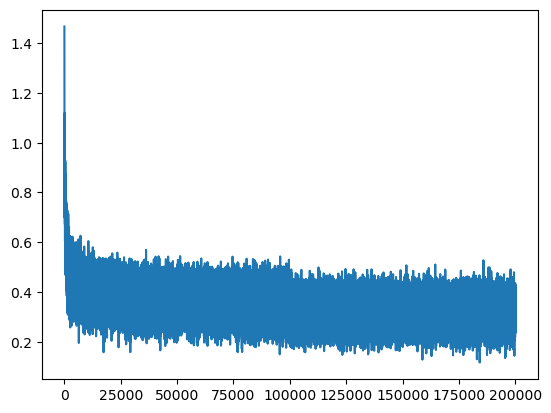

In [73]:
plt.plot(stepi, lossi)

In [74]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1264, grad_fn=<NllLossBackward0>)

In [75]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1660, grad_fn=<NllLossBackward0>)

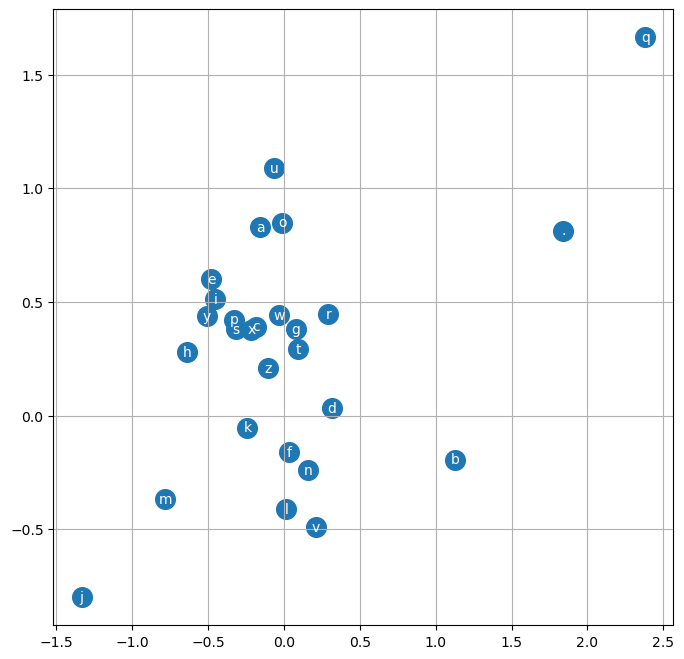

In [76]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [77]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [78]:
#sampling

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carpavea.
jahleigh.
mili.
tatyah.
cassie.
mahnen.
deliah.
jareen.
ner.
kia.
chaiir.
kaleigh.
ham.
jocn.
quint.
sulin.
alian.
quinathoniearisi.
jace.
pirra.
